Experiment 1

| S samples | D droplets | target MSM among non-empty droplets | N cells 建议值 |
| --------: | ---------: | ----------------------------------: | ----------: |
|         8 |  1,000,000 |                                 10% |     235,622 |
|        16 |  1,000,000 |                                 10% |     220,467 |
|        32 |  1,000,000 |                                 10% |     213,599 |
|        48 |  1,000,000 |                                 10% |     211,404 |
|        64 |  1,000,000 |                                 10% |     210,323 |

Experiment 2

|       Scale | S samples | D droplets |   N cells | 说明       |
| ----------: | --------: | ---------: | --------: | -------- |
|       small |        32 |    250,000 |    53,400 | 快速运行，低通量 |
|      medium |        32 |    500,000 |   106,800 | 中等通量     |
|        main |        32 |  1,000,000 |   213,599 | 与正文主模拟一致 |
|       large |        32 |  2,000,000 |   427,198 | 高通量      |
| ultra-large |        32 |  5,000,000 | 1,067,996 | 百万细胞级别   |


Experiment 3

| S samples | D droplets | target MSM | N cells |
| --------: | ---------: | ---------: | ------: |
|        64 |  1,000,000 |        10% | 210,323 |
|        96 |  1,000,000 |        10% | 209,254 |
|       128 |  1,000,000 |        10% | 208,723 |


In [8]:
import torch
import numpy as np
import pandas as pd

from simulator import (
    ProfileRegistry,
    GMMCellEngine,
    NBCellEngine,
    DropletFactory
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# HTO / cell / droplet scale 
H = 128
N_cells = 208723
M_droplets = 1000000

# Distribution choice
DIST_TYPE = "GMM"   # "GMM" or "NB"

# Signal strength
MU_HIGH = 6.0
MU_LOW = 1.0
AMBIENT_LEVEL = 0.1

# NB-specific
DISPERSION = 0.1

In [9]:
registry = ProfileRegistry(
    h_tags=H,
    mu_high=MU_HIGH,
    mu_low=MU_LOW,
    ambient_level=AMBIENT_LEVEL,
    seed=SEED
)
if DIST_TYPE == "GMM":
    engine = GMMCellEngine(
        registry=registry,
        seed=SEED
    )
elif DIST_TYPE == "NB":
    engine = NBCellEngine(
        registry=registry,
        dispersion=DISPERSION,
        seed=SEED
    )
else:
    raise ValueError(f"Unknown DIST_TYPE: {DIST_TYPE}")

In [10]:
cell_matrix, donor_indices = engine.generate(N_cells)

print(cell_matrix.shape)

torch.Size([208723, 128])


In [11]:
factory = DropletFactory(
    m_droplets=M_droplets,
    seed=SEED
)

droplet_matrix, gt = factory.produce(
    cell_matrix,
    donor_indices,
    registry.htos
)

factory.display_report(gt)



=============== HTO Simulation QC Report ===============
Non-Empty Droplets: 188267
--------------------------------------------------
Singlets:           169222   |  89.88%
MSM (Heterotypic):  18847    |  10.01%
SSM (Homotypic):    198      |   0.11%
--------------------------------------------------
Singlet Distribution (Top 5 HTOs):
donor
HTO_sim_127    1403
HTO_sim_124    1400
HTO_sim_14     1397
HTO_sim_84     1388
HTO_sim_109    1380
Name: count, dtype: int64



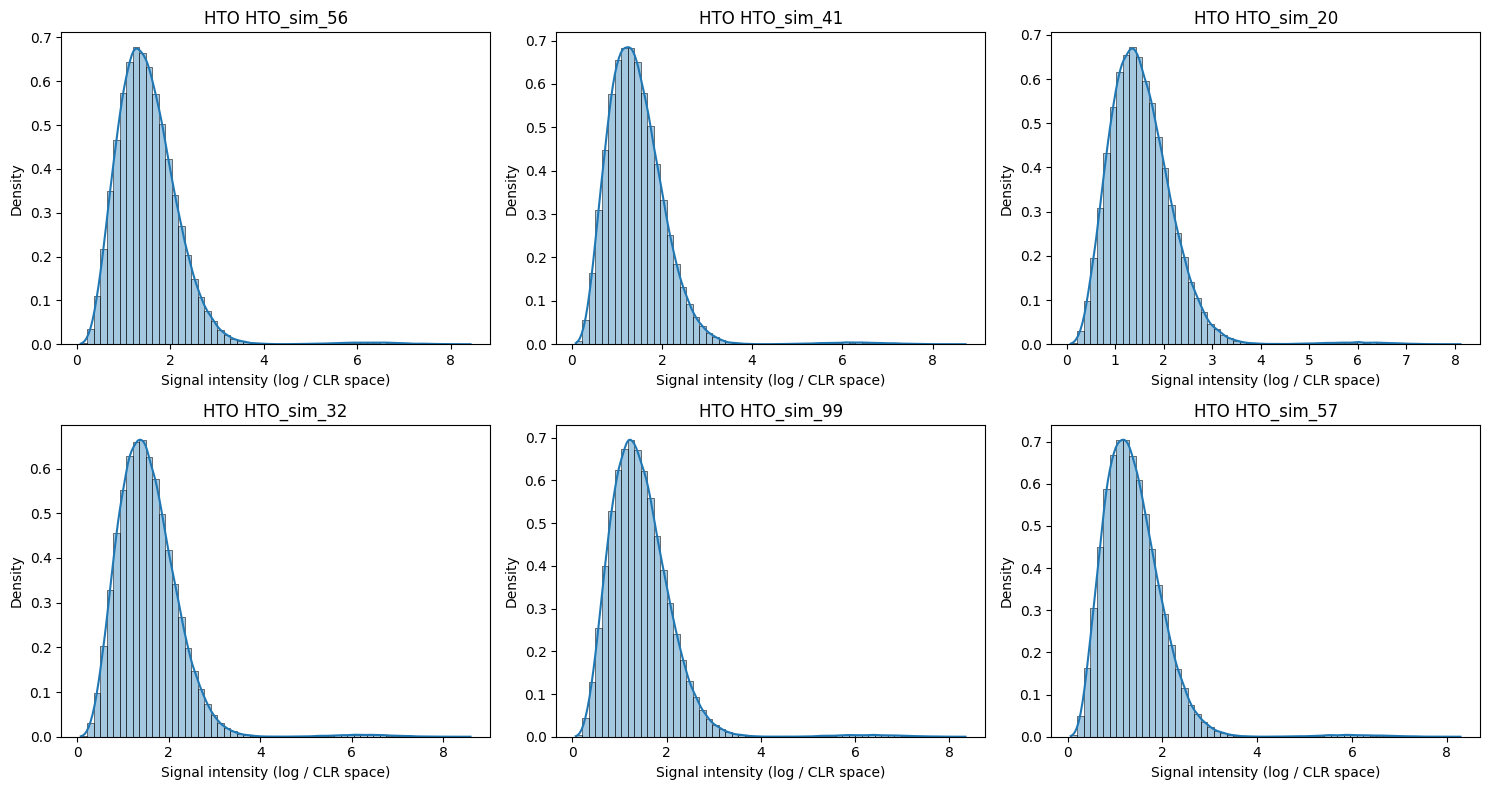

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

singlet_mask = gt["n_cells"] == 1
singlet_matrix = droplet_matrix[singlet_mask.values]


if singlet_matrix.dtype in (torch.int32, torch.int64):
    plot_matrix = torch.log1p(singlet_matrix.float())
    x_label = "log1p(counts)"
else:
    plot_matrix = singlet_matrix
    x_label = "Signal intensity (log / CLR space)"

n_panels = 6
hto_ids = np.random.choice(
    plot_matrix.shape[1],
    size=n_panels,
    replace=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, h in zip(axes, hto_ids):
    data = plot_matrix[:, h].cpu().numpy()

    sns.histplot(
    data,
    bins=60,
    stat="density",
    kde=True,
    ax=ax,
    alpha=0.4
)


    ax.set_title(f"HTO {registry.htos[h]}")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


In [13]:
# =========================
# Convert simulated HTO matrix to integer raw counts
# =========================
import torch

# Make a copy to avoid unexpected in-place side effects
droplet_matrix = droplet_matrix.clone()

# Replace NaN / Inf
droplet_matrix = torch.nan_to_num(
    droplet_matrix,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# Remove negative values
droplet_matrix = torch.clamp(droplet_matrix, min=0)

# Convert continuous simulated signal to integer-like raw counts
droplet_matrix = torch.round(droplet_matrix).to(torch.int64)

# Optional: remove droplets that become all-zero after rounding
hto_total = droplet_matrix.sum(dim=1)
keep = hto_total > 0

droplet_matrix = droplet_matrix[keep]

# 同步过滤 ground truth
gt = gt.loc[keep.cpu().numpy()].reset_index(drop=True)

print("Converted droplet_matrix to integer counts.")
print("droplet_matrix dtype:", droplet_matrix.dtype)
print("droplet_matrix shape:", droplet_matrix.shape)
print("min:", droplet_matrix.min().item())
print("max:", droplet_matrix.max().item())
print("empty droplets after filtering:", int((droplet_matrix.sum(dim=1) == 0).sum().item()))

Converted droplet_matrix to integer counts.
droplet_matrix dtype: torch.int64
droplet_matrix shape: torch.Size([188267, 128])
min: 0
max: 16
empty droplets after filtering: 0


In [14]:
from scipy import sparse
from scipy.io import mmwrite
import gzip
import shutil
from pathlib import Path

OUT_DIR = Path("./10x_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def gzip_file(path, remove_original=False):
    gz_path = Path(str(path) + ".gz")
    with open(path, "rb") as f_in:
        with gzip.open(gz_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    if remove_original:
        Path(path).unlink()
    return gz_path

# Matrix (HTO x droplets)
mm = sparse.coo_matrix(droplet_matrix.T.cpu().numpy())
out_mtx_path = OUT_DIR / "matrix.mtx"
mmwrite(str(out_mtx_path), mm)
gzip_file(out_mtx_path)

# Barcodes
out_barcodes_path = OUT_DIR / "barcodes.tsv"
with open(out_barcodes_path, "wt") as fh:
    for k in range(droplet_matrix.shape[0]):
        fh.write(f"droplet_{k:05d}\n")
gzip_file(out_barcodes_path)

# Features
out_features_path = OUT_DIR / "features.tsv"
with open(out_features_path, "wt") as fh:
    for h in registry.htos:
        fh.write(f"{h}\t{h}\tAntibody Capture\n")
gzip_file(out_features_path)

print("Saved 10x-style files:")
print(out_mtx_path)
print(out_mtx_path.with_suffix(out_mtx_path.suffix + ".gz"))
print(out_barcodes_path)
print(out_barcodes_path.with_suffix(out_barcodes_path.suffix + ".gz"))
print(out_features_path)
print(out_features_path.with_suffix(out_features_path.suffix + ".gz"))

Saved 10x-style files:
10x_output/matrix.mtx
10x_output/matrix.mtx.gz
10x_output/barcodes.tsv
10x_output/barcodes.tsv.gz
10x_output/features.tsv
10x_output/features.tsv.gz
